In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Example dataset
data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})

# Apply Min-Max Normalization
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(data)

# Convert back to DataFrame
normalized_df = pd.DataFrame(
    normalized_data,
    columns=data.columns
)

print("Normalized Data:")
print(normalized_df)

Normalized Data:
      A     B
0  0.00  0.00
1  0.25  0.25
2  0.50  0.50
3  0.75  0.75
4  1.00  1.00


In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Example dataset
data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})

# Apply Min-Max Normalization
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(data)

# Convert back to DataFrame
normalized_df = pd.DataFrame(
    normalized_data,
    columns=data.columns
)

print("Normalized Data:")
print(normalized_df)

Normalized Data:
      A     B
0  0.00  0.00
1  0.25  0.25
2  0.50  0.50
3  0.75  0.75
4  1.00  1.00


In [3]:
import pandas as pd

# Example categorical data
df = pd.DataFrame({
    'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue']
})

# One-Hot Encoding
one_hot = pd.get_dummies(df, columns=['Color'])

print("One-Hot Encoded Data:")
print(one_hot)

One-Hot Encoded Data:
   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False


In [4]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load dataset
tips = sns.load_dataset("tips")

print("Original Data:")
print(tips.head())

# Select numeric columns
numeric_cols = tips.select_dtypes(
    include=['float64', 'int64']
).columns

# -----------------------------
# 1. Normalization
# -----------------------------
scaler_minmax = MinMaxScaler()

tips_normalized = tips.copy()

tips_normalized[numeric_cols] = scaler_minmax.fit_transform(
    tips[numeric_cols]
)

print("\nNormalized Data:")
print(tips_normalized.head())

# -----------------------------
# 2. Standardization
# -----------------------------
scaler_standard = StandardScaler()

tips_standardized = tips.copy()

tips_standardized[numeric_cols] = scaler_standard.fit_transform(
    tips[numeric_cols]
)

print("\nStandardized Data:")
print(tips_standardized.head())

# -----------------------------
# 3. One-Hot Encoding
# -----------------------------
tips_onehot = pd.get_dummies(
    tips,
    columns=['sex', 'smoker', 'day', 'time']
)

print("\nOne-Hot Encoded Data:")
print(tips_onehot.head())

Original Data:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Normalized Data:
   total_bill       tip     sex smoker  day    time  size
0    0.291579  0.001111  Female     No  Sun  Dinner   0.2
1    0.152283  0.073333    Male     No  Sun  Dinner   0.4
2    0.375786  0.277778    Male     No  Sun  Dinner   0.4
3    0.431713  0.256667    Male     No  Sun  Dinner   0.2
4    0.450775  0.290000  Female     No  Sun  Dinner   0.6

Standardized Data:
   total_bill       tip     sex smoker  day    time      size
0   -0.314711 -1.439947  Female     No  Sun  Dinner -0.600193
1   -1.063235 -0.969205    Male     No  Sun  Dinner  0.453383
2    0.137780  0.363356    Male     No  Sun  Dinner  0.453383
3    0.438315  0.225754    

Explained Variance Ratio:
[0.72627656 0.1730423 ]

PCA Result:
        PC1       PC2
0 -1.348415  0.426746
1 -0.955740  1.093576
2  0.540971  0.122324
3  0.067789 -0.674616
4  1.408308  0.847661


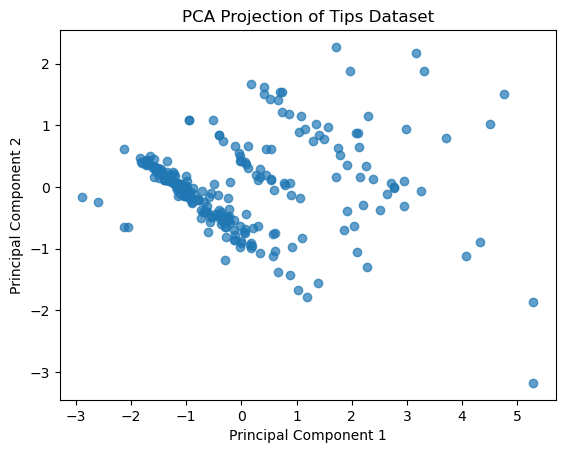

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
tips = sns.load_dataset("tips")

# Select numeric columns
numeric_cols = tips.select_dtypes(
    include=['float64', 'int64']
)

# Step 1: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_cols)

# Step 2: Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Step 3: Create DataFrame
pca_df = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2']
)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nPCA Result:")
print(pca_df.head())

# Step 4: Plot PCA
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.7
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Tips Dataset')
plt.show()

Explained Variance Ratio:
[0.9912126 0.0087874]

LDA Result:
        LD1       LD2  target
0  8.061800 -0.300421       0
1  7.128688  0.786660       0
2  7.489828  0.265384       0
3  6.813201  0.670631       0
4  8.132309 -0.514463       0


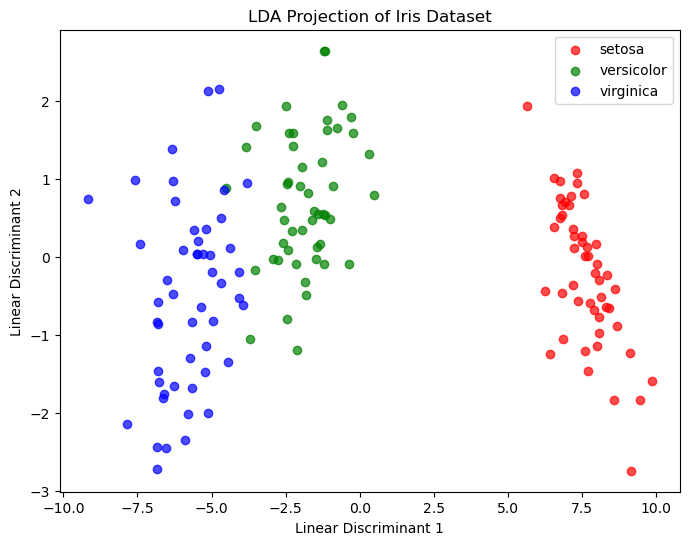

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda.fit_transform(X, y)

# Create DataFrame
lda_df = pd.DataFrame(
    X_lda,
    columns=['LD1', 'LD2']
)

lda_df['target'] = y

print("Explained Variance Ratio:")
print(lda.explained_variance_ratio_)

print("\nLDA Result:")
print(lda_df.head())

# Visualize LDA
plt.figure(figsize=(8, 6))

for label, color in zip(
    [0, 1, 2],
    ['red', 'green', 'blue']
):
    plt.scatter(
        lda_df.loc[lda_df['target'] == label, 'LD1'],
        lda_df.loc[lda_df['target'] == label, 'LD2'],
        label=iris.target_names[label],
        color=color,
        alpha=0.7
    )

plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.title('LDA Projection of Iris Dataset')
plt.legend()
plt.show()

t-SNE Result:
       TSNE1     TSNE2  target
0 -25.228506 -0.747387       0
1 -22.511786  0.250785       0
2 -22.652061 -1.010731       0
3 -22.189922 -0.606391       0
4 -25.180489 -1.189469       0


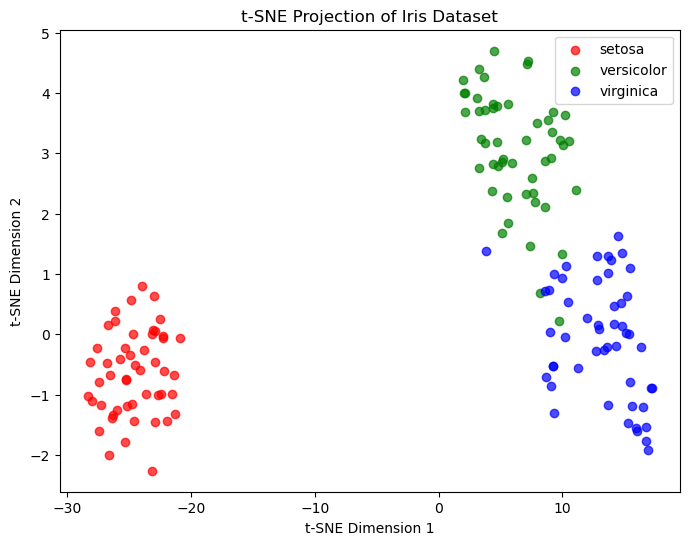

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.manifold import TSNE

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000
)

X_tsne = tsne.fit_transform(X)

# Create DataFrame
tsne_df = pd.DataFrame(
    X_tsne,
    columns=['TSNE1', 'TSNE2']
)

tsne_df['target'] = y

print("t-SNE Result:")
print(tsne_df.head())

# Visualize t-SNE
plt.figure(figsize=(8, 6))

for label, color in zip(
    [0, 1, 2],
    ['red', 'green', 'blue']
):
    plt.scatter(
        tsne_df.loc[tsne_df['target'] == label, 'TSNE1'],
        tsne_df.loc[tsne_df['target'] == label, 'TSNE2'],
        label=iris.target_names[label],
        color=color,
        alpha=0.7
    )

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Projection of Iris Dataset')
plt.legend()
plt.show()